# Entrenamiento de Random Forest con ToN_IoT

En este notebook seguimos la misma idea de `rf_train_iot.ipynb`, pero adaptando el experimento al subconjunto de red de ToN_IoT.

Vamos a resolver un problema binario usando la variable `label` como objetivo, que distingue entre `BENIGN` y `ATTACK`.

La columna `type` se elimina del conjunto de características para evitar fuga de información, y solo la usamos para análisis posterior si fuera necesario.

Nota: el CSV disponible en el proyecto contiene `211 043` flujos en total.

        

In [7]:
import time
import joblib
import numpy as np
import polars as pl
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [8]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [9]:
# ==========================================
# 3. OPTUNA MULTIOBJETIVO (F1-MACRO Y LATENCIA)
# ==========================================

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 30)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    f1_scores = []
    latencies = []

    for train_idx_cv, val_idx_cv in skf.split(X_full_train_np, y_full_train):
        X_train_cv, X_val_cv = X_full_train_np[train_idx_cv], X_full_train_np[val_idx_cv]
        y_train_cv, y_val_cv = y_full_train[train_idx_cv], y_full_train[val_idx_cv]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1,
            random_state=42,
            class_weight="balanced",
        )

        model.fit(X_train_cv, y_train_cv)
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average="binary", zero_division=0))

        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]
        _ = model.predict(X_lat[:min(500, len(X_lat))])

        rep_lat = []
        for _ in range(3):
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(rep_lat)))

    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies))
    std_f1 = float(np.std(f1_scores))

    trial.set_user_attr("f1_std", std_f1)

    return avg_f1, avg_lat

study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="ton_iot_rf_optimization_cv",
)

print("Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para ToN_IoT...")
print("Evaluando F1-macro multiclase y latencia media por muestra.")

study.optimize(objective, n_trials=50)

trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "max_depth": t.params["max_depth"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t in study.best_trials,
        })

df_results = pl.DataFrame(trials_data)
results_path = "rf_ton_iot_trials_results_cv.csv"
df_results.write_csv(results_path)

print(f"\nResultados guardados en '{results_path}'")
display(df_results.sort("f1_macro", descending=True).head())


[I 2026-04-29 20:56:50,762] A new study created in memory with name: ton_iot_rf_optimization_cv


Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para ToN_IoT...
Evaluando F1-macro multiclase y latencia media por muestra.


[I 2026-04-29 20:56:58,420] Trial 0 finished with values: [0.9978873016835769, 0.007217443955596536] and parameters: {'n_estimators': 550, 'max_depth': 19}.
[I 2026-04-29 20:56:59,634] Trial 1 finished with values: [0.9975453536654894, 0.0014466449540729324] and parameters: {'n_estimators': 50, 'max_depth': 13}.
[I 2026-04-29 20:57:06,743] Trial 2 finished with values: [0.9499798399639877, 0.006824831656154453] and parameters: {'n_estimators': 550, 'max_depth': 3}.
[I 2026-04-29 20:57:12,044] Trial 3 finished with values: [0.9977785840906671, 0.005723725552282607] and parameters: {'n_estimators': 350, 'max_depth': 15}.
[I 2026-04-29 20:57:13,305] Trial 4 finished with values: [0.9978291003316332, 0.001460895492669402] and parameters: {'n_estimators': 50, 'max_depth': 18}.
[I 2026-04-29 20:57:21,529] Trial 5 finished with values: [0.9964225012911663, 0.007619295621083843] and parameters: {'n_estimators': 600, 'max_depth': 8}.
[I 2026-04-29 20:57:26,130] Trial 6 finished with values: [0.


Resultados guardados en 'rf_ton_iot_trials_results_cv.csv'


n_estimators,max_depth,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,f64,f64,f64,bool
450,20,0.997907,0.000082,0.005976,true
300,20,0.997891,0.000072,0.00444,true
550,19,0.997887,0.000064,0.007217,false
200,21,0.997868,0.000075,0.003868,true
500,23,0.997849,0.000118,0.00688,false


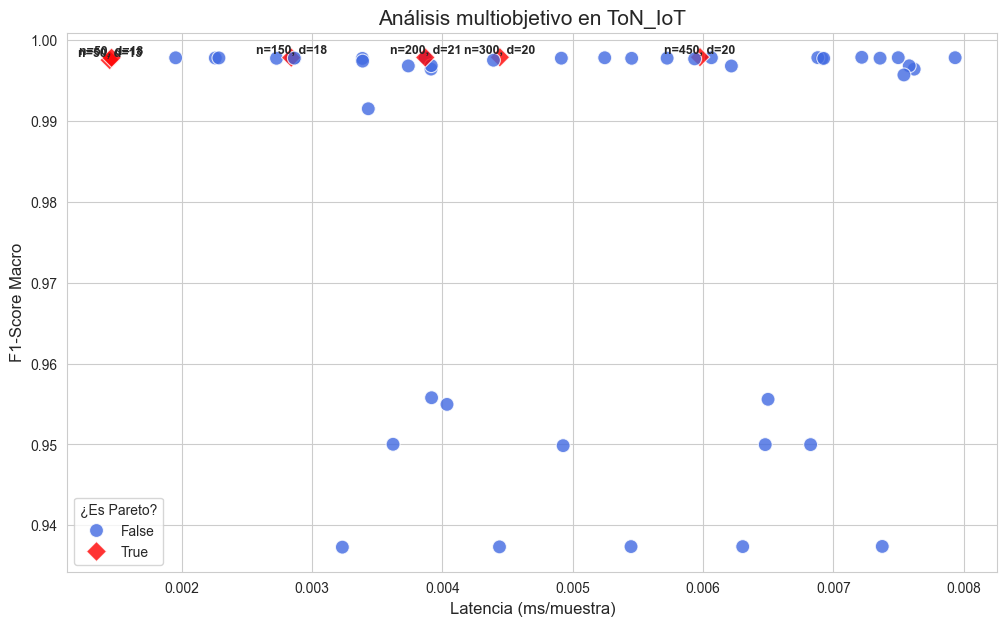

In [10]:
df = pl.read_csv("rf_ton_iot_trials_results_cv.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_macro"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8,
)

pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        fontsize=9,
        fontweight="bold",
        ha="center",
    )

plt.title("Análisis multiobjetivo en ToN_IoT", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")
plt.show()

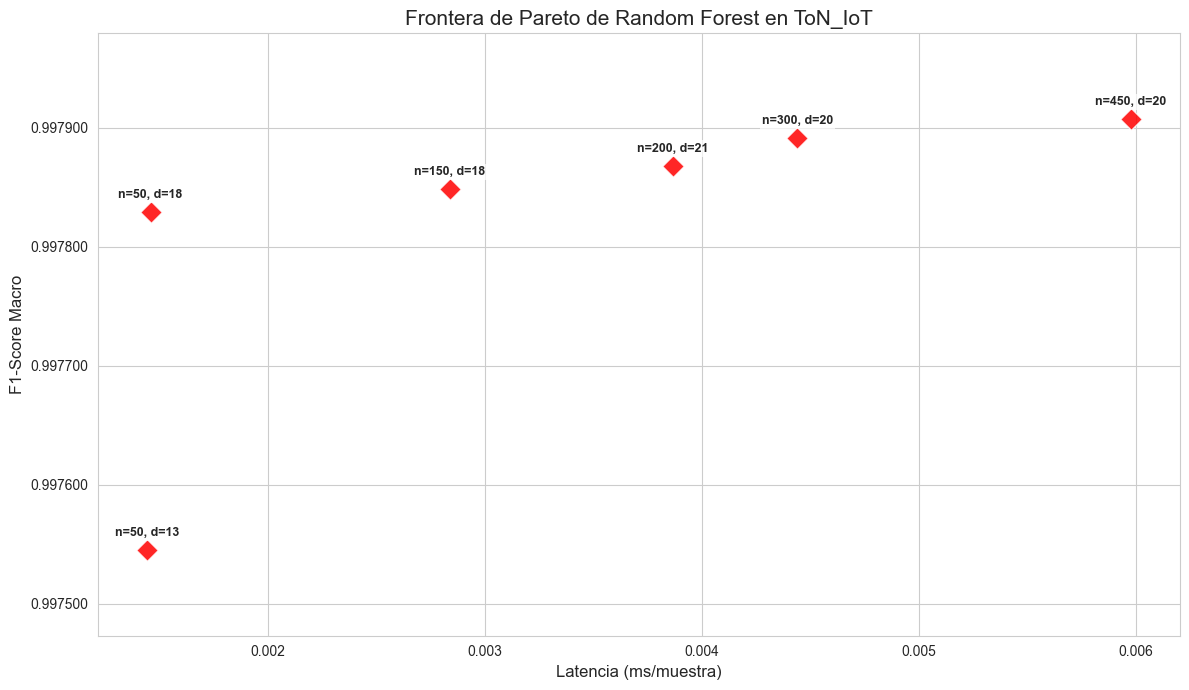

n_estimators,max_depth,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,f64,f64,f64,bool
50,13,0.997545,0.000048,0.001447,true
50,18,0.997829,0.000024,0.001461,true
150,18,0.997848,0.000081,0.00284,true
200,21,0.997868,0.000075,0.003868,true
300,20,0.997891,0.000072,0.00444,true
450,20,0.997907,0.000082,0.005976,true


In [11]:
# Representamos unicamente la frontera de Pareto
from matplotlib.ticker import FormatStrFormatter

df = pl.read_csv("rf_ton_iot_trials_results_cv.csv")
pareto = (
    df
    .filter(pl.col("is_pareto") == True)
    .sort("latency_ms")
)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = plt.gca()

sns.scatterplot(
    x=pareto["latency_ms"].to_numpy(),
    y=pareto["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.85,
    ax=ax,
)

ax.ticklabel_format(style="plain", axis="y", useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.6f"))

y_vals = pareto["f1_macro"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.2, 0.00005)
    ax.set_ylim(y_min - margin, y_max + margin)

for row in pareto.iter_rows(named=True):
    ax.annotate(
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_macro"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5),
    )

plt.title("Frontera de Pareto de Random Forest en ToN_IoT", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.tight_layout()
plt.show()

display(pareto)

In [12]:
# ==========================================
#  EVALUACION FINAL SOBRE TEST
# ==========================================

candidatos = [
    {"n": 50,  "d": 13, "nombre": "Candidato 1"},
    {"n": 50,  "d": 18, "nombre": "Candidato 2"},
    {"n": 150, "d": 18, "nombre": "Candidato 3"},
    {"n": 200, "d": 21, "nombre": "Candidato 4"},
    {"n": 300, "d": 20, "nombre": "Candidato 5"},
    {"n": 450, "d": 20, "nombre": "Candidato 6"}
]

resultados_finales = []
mejor_modelo = None
mejor_resumen = None

print("--- EVALUACION FINAL SOBRE EL SET DE TEST ---\n")

for c in candidatos:
    print(f"Probando: {c['nombre']} (n={c['n']}, d={c['d']})...")

    model = RandomForestClassifier(
        n_estimators=c["n"],
        max_depth=c["d"],
        n_jobs=-1,
        random_state=42,
        class_weight="balanced_subsample",
    )
    model.fit(X_full_train_np, y_full_train)

    subset = min(20000, len(X_test_np))
    X_lat = X_test_np[:subset]
    _ = model.predict(X_lat[:min(500, len(X_lat))])

    rep_lat = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = model.predict(X_lat)
        t1 = time.perf_counter()
        rep_lat.append((t1 - t0) / len(X_lat) * 1000)

    y_pred = model.predict(X_test_np)

    latencia = float(np.mean(rep_lat))
    f1_test = float(f1_score(y_test_np, y_pred, average="macro", zero_division=0))
    acc_test = float(accuracy_score(y_test_np, y_pred))

    print(classification_report(y_test_np, y_pred, digits=4, zero_division=0))

    resumen = {
        "Perfil": c["nombre"],
        "n_estimators": c["n"],
        "max_depth": c["d"],
        "F1_Macro_Test": f1_test,
        "Accuracy_Test": acc_test,
        "Latencia_ms": latencia,
    }
    resultados_finales.append(resumen)

    if (
        mejor_resumen is None
        or resumen["F1_Macro_Test"] > mejor_resumen["F1_Macro_Test"]
        or (
            resumen["F1_Macro_Test"] == mejor_resumen["F1_Macro_Test"]
            and resumen["Latencia_ms"] < mejor_resumen["Latencia_ms"]
        )
    ):
        mejor_resumen = resumen
        mejor_modelo = model


df_final = pl.DataFrame(resultados_finales).sort(["F1_Macro_Test", "Latencia_ms"], descending=[True, False])
print("\n" + "=" * 60)
print("              TABLA COMPARATIVA FINAL")
print("=" * 60)
display(df_final)

if mejor_modelo is not None:
    model_path = "rf_ton_iot_best.joblib"
    joblib.dump(mejor_modelo, model_path)
    print(f"\nMejor modelo guardado en: {model_path}")
    print(mejor_resumen)

--- EVALUACION FINAL SOBRE EL SET DE TEST ---

Probando: Candidato 1 (n=50, d=13)...
              precision    recall  f1-score   support

           0     0.9912    0.9963    0.9938     10000
           1     0.9988    0.9973    0.9981     32209

    accuracy                         0.9970     42209
   macro avg     0.9950    0.9968    0.9959     42209
weighted avg     0.9970    0.9970    0.9970     42209

Probando: Candidato 2 (n=50, d=18)...
              precision    recall  f1-score   support

           0     0.9923    0.9968    0.9946     10000
           1     0.9990    0.9976    0.9983     32209

    accuracy                         0.9974     42209
   macro avg     0.9957    0.9972    0.9964     42209
weighted avg     0.9974    0.9974    0.9974     42209

Probando: Candidato 3 (n=150, d=18)...
              precision    recall  f1-score   support

           0     0.9922    0.9967    0.9945     10000
           1     0.9990    0.9976    0.9983     32209

    accuracy        

Perfil,n_estimators,max_depth,F1_Macro_Test,Accuracy_Test,Latencia_ms
str,i64,i64,f64,f64,f64
"""Candidato 4""",200,21,0.996598,0.997536,0.004955
"""Candidato 2""",50,18,0.996434,0.997418,0.001459
"""Candidato 3""",150,18,0.996369,0.99737,0.002886
"""Candidato 6""",450,20,0.996369,0.99737,0.00759
"""Candidato 5""",300,20,0.996271,0.997299,0.004452
"""Candidato 1""",50,13,0.995912,0.997039,0.001468



Mejor modelo guardado en: rf_ton_iot_best.joblib
{'Perfil': 'Candidato 4', 'n_estimators': 200, 'max_depth': 21, 'F1_Macro_Test': 0.996598395325508, 'Accuracy_Test': 0.9975360705062901, 'Latencia_ms': 0.004954696215766792}
